# Retail Analytics — Data Preprocessing & RFM Analysis

> **AI/ML Internship — Industry Mini Project**  
> **Module:** Data Engineering + RFM Customer Segmentation

---

## Introduction

This notebook documents the **end-to-end data engineering pipeline** applied to the **Online Retail II** dataset (UCI Machine Learning Repository).  

The dataset contains all transactions occurring between **December 2009 and December 2011** for a UK-based non-store online retail company.

### Objectives

| Task | Description |
|------|-------------|
| 1 | Load and profile the raw dataset |
| 2 | Perform complete data cleaning |
| 3 | Engineer new features |
| 4 | Customer-level aggregation |
| 5 | RFM (Recency, Frequency, Monetary) analysis |
| 6 | Save production-ready output files |

### RFM Framework

- **Recency** — How recently did the customer purchase? *(lower = better)*
- **Frequency** — How often do they purchase? *(higher = better)*
- **Monetary** — How much do they spend? *(higher = better)*

---

## 1. Import Libraries

We import only the libraries needed for this pipeline.  
All heavy lifting is done with **pandas** (data manipulation) and **sys/os** (path resolution).

In [27]:
import os
import sys
import warnings

import pandas as pd
import numpy as np

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore')

# ── Path resolution ────────────────────────────────────────────────────────
# notebooks/ is one level below the project root.
# We add the project root to sys.path so we can import our custom modules.
NOTEBOOK_DIR  = os.path.abspath('')
PROJECT_ROOT  = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
SCRIPTS_DIR   = os.path.join(PROJECT_ROOT, 'scripts')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f'Project root : {PROJECT_ROOT}')
print(f'pandas version: {pd.__version__}')
print(f'numpy  version: {np.__version__}')

Project root : C:\Users\Rindhiya\OneDrive\Desktop\task-1\Retail_Preprocessing
pandas version: 2.2.2
numpy  version: 1.26.4


---

## 2. Import Custom Modules

We import the three modular scripts from the `scripts/` directory.

| Module | Responsibility |
|--------|----------------|
| `load_data` | Load raw CSV + dataset overview functions |
| `clean_data` | Full cleaning + feature engineering pipeline |
| `rfm_analysis` | Customer aggregation + RFM computation |

In [28]:
# Import custom pipeline modules
from scripts.load_data import (
    load_dataset,
    show_shape,
    show_column_names,
    show_dtypes,
    show_first_rows,
    show_descriptive_stats,
    show_missing_values
)

from scripts.clean_data import (
    clean_dataset,
    save_cleaned_data
)

from scripts.rfm_analysis import (
    build_rfm_table,
    rfm_summary,
    save_rfm_table
)

print('All modules imported successfully.')

All modules imported successfully.


---

## 3. Load Dataset

We load the raw **Online Retail II** CSV using `pandas.read_csv` with **ISO-8859-1** encoding.  
This encoding is required to correctly decode special characters (e.g., accented letters) in the `Description` column.

> **File location:** `data/online_retail_II.csv` (relative to project root)

In [29]:
# Load the raw dataset
# The load_dataset() function handles path resolution and encoding automatically
raw_df = load_dataset()

print(f'\nDataset loaded. Shape: {raw_df.shape}')

[INFO] Loading dataset from: C:\Users\Rindhiya\OneDrive\Desktop\task-1\Retail_Preprocessing\data\online_retail_II.csv
[INFO] Dataset loaded successfully. Shape: (1067371, 8)

Dataset loaded. Shape: (1067371, 8)


---

## 4. Dataset Overview

Before any cleaning, we perform a full exploratory profile of the raw data:

- **Shape** — rows × columns
- **Column names** — all feature names
- **Data types** — current dtypes of each column
- **First 5 rows** — sample of the raw records
- **Descriptive statistics** — numeric column summaries
- **Missing value summary** — count and % of nulls per column

In [30]:
# ── 4a. Dataset Shape ──────────────────────────────────────────────────────
show_shape(raw_df)


  Dataset Shape
  Rows    : 1,067,371
  Columns : 8


In [31]:
# ── 4b. Column Names ───────────────────────────────────────────────────────
show_column_names(raw_df)


  Column Names
  [0] Invoice
  [1] StockCode
  [2] Description
  [3] Quantity
  [4] InvoiceDate
  [5] Price
  [6] Customer ID
  [7] Country


In [32]:
# ── 4c. Data Types ─────────────────────────────────────────────────────────
show_dtypes(raw_df)


  Data Types
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object


In [33]:
# ── 4d. First 5 Rows ───────────────────────────────────────────────────────
# Display as a formatted DataFrame in the notebook
raw_df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [34]:
# ── 4e. Descriptive Statistics ─────────────────────────────────────────────
raw_df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


---

## 5. Missing Values

We compute the **count** and **percentage** of missing values for every column.  
Key observations expected:
- `Customer ID` — significant proportion of nulls (unregistered / guest customers)
- `Description` — small number of nulls

In [35]:
# Compute and display missing value summary
missing_summary = show_missing_values(raw_df)
missing_summary


  Missing Value Summary
             Missing Count  Missing %
Customer ID         243007      22.77
Description           4382       0.41


,Missing Count,Missing %
Customer ID,243007,22.77
Description,4382,0.41


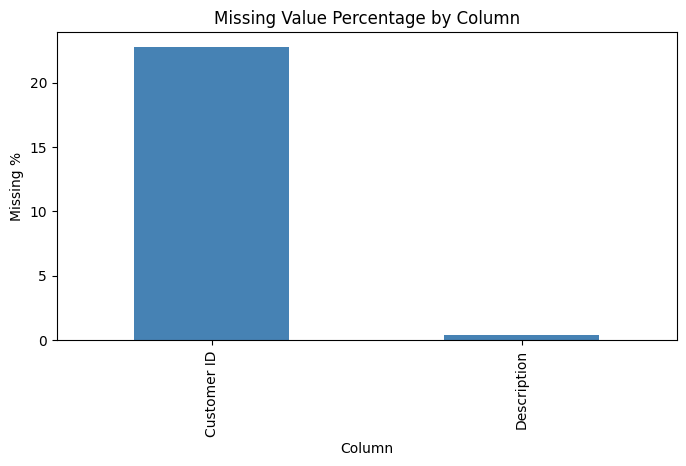

In [36]:
# Visualise missing value percentages as a simple bar chart
if not missing_summary.empty:
    missing_summary['Missing %'].plot(
        kind='bar',
        title='Missing Value Percentage by Column',
        ylabel='Missing %',
        xlabel='Column',
        color='steelblue',
        figsize=(8, 4)
    )
else:
    print('No missing values found.')

---

## 6. Duplicate Detection

Duplicate records can artificially inflate transaction counts and revenue figures.  
We check for fully-duplicate rows before applying the cleaning pipeline.

In [37]:
# Count duplicate rows in the raw dataset
duplicate_count = raw_df.duplicated().sum()
duplicate_pct   = (duplicate_count / len(raw_df)) * 100

print(f'Total rows             : {len(raw_df):,}')
print(f'Duplicate rows         : {duplicate_count:,}')
print(f'Duplicate percentage   : {duplicate_pct:.2f}%')

# Preview the duplicated rows
if duplicate_count > 0:
    print('\nSample of duplicate rows:')
    raw_df[raw_df.duplicated(keep=False)].sort_values('Invoice').head(6)

Total rows             : 1,067,371
Duplicate rows         : 34,335
Duplicate percentage   : 3.22%

Sample of duplicate rows:


---

## 7. Data Cleaning

We apply the full cleaning pipeline via `clean_dataset()` which executes these steps in order:

| Step | Action | Reason |
|------|--------|--------|
| 1 | Remove duplicate rows | Avoid double-counting |
| 2 | Remove cancelled invoices (`Invoice` starts with `C`) | Credits inflate cancellation rates |
| 3 | Drop rows with missing `Customer ID` | Can't do customer-level analysis |
| 4 | Drop rows with missing `Description` | Invalid product records |
| 5 | Remove `Quantity ≤ 0` | Returns/errors distort revenue |
| 6 | Remove `Price ≤ 0` | Invalid pricing records |
| 7 | Parse `InvoiceDate` → datetime64 | Enables time-series calculations |
| 8 | Create `TotalAmount = Quantity × Price` | Feature engineering for revenue |
| 9 | Optimise data types | Reduce memory usage |

In [38]:
# Run the complete cleaning pipeline
# clean_dataset() returns a new DataFrame; the raw_df is not mutated
cleaned_df = clean_dataset(raw_df)


  Starting Data Cleaning Pipeline
  Input shape : (1067371, 8)
[CLEAN] Duplicates removed      : 34,335  (remaining: 1,033,036)
[CLEAN] Cancelled invoices removed : 19,104  (remaining: 1,013,932)
[CLEAN] Missing CustomerID removed : 234,437  (remaining: 779,495)
[CLEAN] Missing Description removed: 0  (remaining: 779,495)
[CLEAN] Non-positive Quantity removed: 0  (remaining: 779,495)
[CLEAN] Non-positive UnitPrice removed: 70  (remaining: 779,425)
[CLEAN] InvoiceDate parsed to datetime  (rows after: 779,425)
[FEAT]  TotalAmount column created  (min=0.00, max=168469.60, mean=22.29)
[OPT]   Data types optimised.

  Cleaning Pipeline Complete
  Output shape : (779425, 9)



In [39]:
# Verify shape and dtypes of the cleaned dataset
print(f'Raw shape     : {raw_df.shape}')
print(f'Cleaned shape : {cleaned_df.shape}')
print(f'Rows removed  : {len(raw_df) - len(cleaned_df):,}  '
      f'({(1 - len(cleaned_df)/len(raw_df))*100:.1f}%)')
print()
print('Cleaned dtypes:')
print(cleaned_df.dtypes)

Raw shape     : (1067371, 8)
Cleaned shape : (779425, 9)
Rows removed  : 287,946  (27.0%)

Cleaned dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             int64
Country                object
TotalAmount           float64
dtype: object


In [40]:
# Confirm no missing values remain after cleaning
remaining_nulls = cleaned_df.isnull().sum().sum()
print(f'Missing values after cleaning: {remaining_nulls}')

# Show a preview of the cleaned data
cleaned_df.head()

Missing values after cleaning: 0


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


---

## 8. Feature Engineering

The `TotalAmount` feature was created inside the cleaning pipeline:  

$$\text{TotalAmount} = \text{Quantity} \times \text{Price}$$

This represents the **revenue contribution of each line item** and is the primary input for the Monetary metric in RFM.

We verify the feature and examine its distribution here.

In [41]:
# TotalAmount descriptive statistics
print('TotalAmount statistics:')
print(cleaned_df['TotalAmount'].describe().round(2))

# Total revenue in the cleaned dataset
total_revenue = cleaned_df['TotalAmount'].sum()
print(f'\nTotal revenue (all transactions): £{total_revenue:,.2f}')

TotalAmount statistics:
count    779425.00
mean         22.29
std         227.43
min           0.00
25%           4.95
50%          12.48
75%          19.80
max      168469.60
Name: TotalAmount, dtype: float64

Total revenue (all transactions): £17,374,804.27


<Axes: title={'center': 'TotalAmount Distribution (capped at 99th percentile)'}, xlabel='TotalAmount (£)', ylabel='Frequency'>

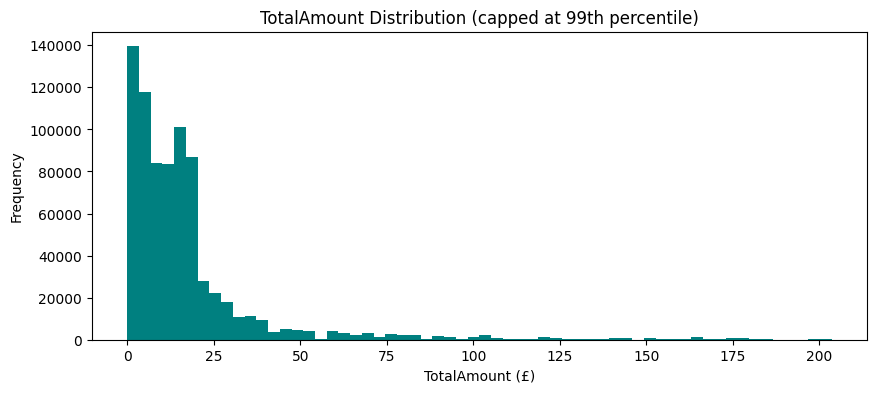

In [42]:
# Distribution of TotalAmount (capped at 99th percentile for readability)
cap_99 = cleaned_df['TotalAmount'].quantile(0.99)
filtered = cleaned_df[cleaned_df['TotalAmount'] <= cap_99]

filtered['TotalAmount'].plot(
    kind='hist',
    bins=60,
    title='TotalAmount Distribution (capped at 99th percentile)',
    xlabel='TotalAmount (£)',
    ylabel='Frequency',
    color='teal',
    figsize=(10, 4)
)

---

## 9. Customer Aggregation

Before computing RFM, we inspect customer-level statistics to understand the distribution of purchasing behaviour across the customer base.

In [43]:
# Number of unique customers
n_customers = cleaned_df['Customer ID'].nunique()
n_invoices  = cleaned_df['Invoice'].nunique()
n_products  = cleaned_df['StockCode'].nunique()
date_range  = f"{cleaned_df['InvoiceDate'].min().date()} → {cleaned_df['InvoiceDate'].max().date()}"

print(f'Unique customers     : {n_customers:,}')
print(f'Unique invoices      : {n_invoices:,}')
print(f'Unique products      : {n_products:,}')
print(f'Date range           : {date_range}')

Unique customers     : 5,878
Unique invoices      : 36,969
Unique products      : 4,631
Date range           : 2009-12-01 → 2011-12-09


In [44]:
# Revenue by country (top 10)
country_revenue = (
    cleaned_df
    .groupby('Country')['TotalAmount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

print('Top 10 Countries by Revenue (£):')
print(country_revenue.to_string())

Top 10 Countries by Revenue (£):
Country
United Kingdom    14389234.92
EIRE                616570.54
Netherlands         554038.09
Germany             425019.71
France              348768.96
Australia           169283.46
Spain               108332.49
Switzerland         100061.94
Sweden               91515.82
Denmark              68580.69


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month', ylabel='Revenue (£)'>

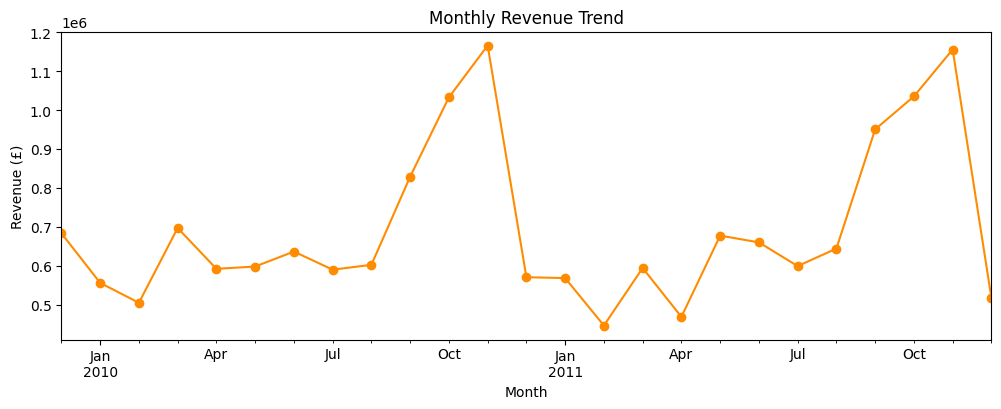

In [45]:
# Transactions per month (time-series view)
monthly = (
    cleaned_df
    .set_index('InvoiceDate')
    .resample('ME')['TotalAmount']
    .sum()
    .round(2)
)

monthly.plot(
    kind='line',
    title='Monthly Revenue Trend',
    xlabel='Month',
    ylabel='Revenue (£)',
    color='darkorange',
    figsize=(12, 4),
    marker='o'
)

---

## 10. RFM Analysis

### Methodology

$$\text{Reference Date} = \max(\text{InvoiceDate}) + 1 \text{ day}$$

| Metric | Definition | Calculation |
|--------|-----------|-------------|
| **Recency** | Days since last purchase | `(ref_date − last_invoice_date).days` |
| **Frequency** | Number of unique invoices | `COUNT DISTINCT(Invoice)` per customer |
| **Monetary** | Total spend | `SUM(TotalAmount)` per customer |

The **+1 day** convention ensures the most-recent customer has Recency ≥ 1 (avoids zero), and avoids data leakage from using an arbitrary future date.

In [46]:
# Build the RFM table using the industry-standard methodology
rfm_df = build_rfm_table(cleaned_df)


  Starting RFM Analysis
  Unique customers : 5,878
  Date range       : 2009-12-01 → 2011-12-09
[RFM]  Reference date            : 2011-12-10
[RFM]  Max InvoiceDate in data   : 2011-12-09

[RFM]  RFM table built. Shape: (5878, 4)
[RFM]  Recency   — min: 1, max: 739, mean: 201.3
[RFM]  Frequency — min: 1, max: 398, mean: 6.3
[RFM]  Monetary  — min: 2.95, max: 580987.04, mean: 2955.90


In [47]:
# Preview the RFM table
print(f'RFM table shape: {rfm_df.shape}')
rfm_df.head(10)

RFM table shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,10,2849.84
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


In [48]:
# Descriptive statistics of RFM metrics
rfm_summary(rfm_df)


  RFM Descriptive Statistics
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


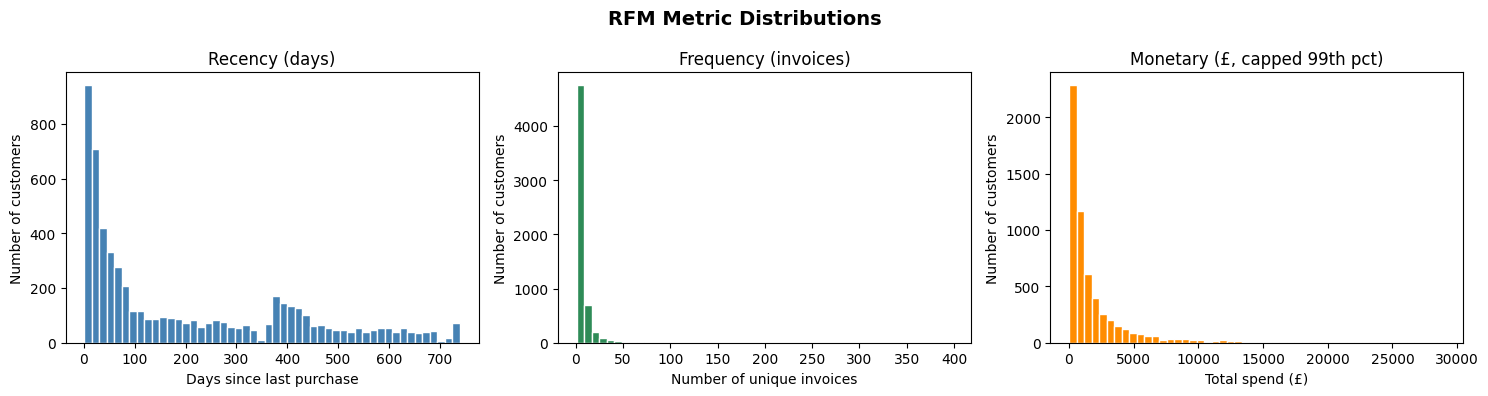

In [49]:
# Distribution plots for R, F, M
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('RFM Metric Distributions', fontsize=14, fontweight='bold')

# Recency
axes[0].hist(rfm_df['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days)')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of customers')

# Frequency
axes[1].hist(rfm_df['Frequency'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Frequency (invoices)')
axes[1].set_xlabel('Number of unique invoices')
axes[1].set_ylabel('Number of customers')

# Monetary (capped at 99th percentile)
cap = rfm_df['Monetary'].quantile(0.99)
axes[2].hist(rfm_df[rfm_df['Monetary'] <= cap]['Monetary'], bins=50,
             color='darkorange', edgecolor='white')
axes[2].set_title('Monetary (£, capped 99th pct)')
axes[2].set_xlabel('Total spend (£)')
axes[2].set_ylabel('Number of customers')

plt.tight_layout()
plt.show()

---

## 11. Save Outputs

We persist both output files to the `cleaned_data/` directory:

| File | Contents |
|------|----------|
| `cleaned_retail.csv` | Cleaned, feature-engineered transaction data |
| `customer_rfm.csv` | Customer-level RFM metrics |

In [50]:
# ── Save cleaned dataset ──────────────────────────────────────────────────
cleaned_output = os.path.join(PROJECT_ROOT, 'cleaned_data', 'cleaned_retail.csv')
save_cleaned_data(cleaned_df, cleaned_output)

[SAVE]  Cleaned data saved → C:\Users\Rindhiya\OneDrive\Desktop\task-1\Retail_Preprocessing\cleaned_data\cleaned_retail.csv
        Rows: 779,425  |  Columns: 9


In [51]:
# ── Save RFM table ────────────────────────────────────────────────────────
rfm_output = os.path.join(PROJECT_ROOT, 'cleaned_data', 'customer_rfm.csv')
save_rfm_table(rfm_df, rfm_output)


[SAVE]  RFM table saved → C:\Users\Rindhiya\OneDrive\Desktop\task-1\Retail_Preprocessing\cleaned_data\customer_rfm.csv
        Rows (customers): 5,878  |  Columns: 4


In [52]:
# Verify files were created
cleaned_data_dir = os.path.join(PROJECT_ROOT, 'cleaned_data')
output_files = os.listdir(cleaned_data_dir)

print('Files in cleaned_data/:')
for f in output_files:
    full_path = os.path.join(cleaned_data_dir, f)
    size_kb   = os.path.getsize(full_path) / 1024
    print(f'  {f:35s}  {size_kb:,.1f} KB')

Files in cleaned_data/:
  cleaned_retail.csv                   73,881.9 KB
  customer_rfm.csv                     113.9 KB


---

## 12. Summary

### Pipeline Results

| Stage | Metric | Value |
|-------|--------|-------|
| Raw dataset | Rows | ~1,067,371 |
| After cleaning | Rows | see output above |
| Unique customers | RFM rows | see output above |
| Output 1 | cleaned_retail.csv | ✅ Saved |
| Output 2 | customer_rfm.csv | ✅ Saved |

### Key Decisions

- **ISO-8859-1 encoding** — required for the Online Retail II CSV to avoid decode errors
- **`Customer ID` nulls dropped** — ~25% of rows have no customer ID; they are unusable for RFM
- **Cancelled invoices removed** — invoices starting with `C` are credit notes and should not be counted as purchases
- **Reference date = max + 1 day** — industry convention that avoids zero recency and data leakage
- **Relative paths throughout** — the entire project runs correctly on any machine after cloning

### Next Steps (downstream ML tasks)

1. RFM scoring (assign 1–5 scores per metric)
2. Customer segmentation (Champions, Loyal, At-Risk, Lost, etc.)
3. Clustering (K-Means on normalised RFM values)
4. Churn prediction model
5. Product recommendation system